In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()

df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
df['progression'] = diabetes.target
print(df.head())
print(df.shape)

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  progression  
0 -0.002592  0.019907 -0.017646        151.0  
1 -0.039493 -0.068332 -0.092204         75.0  
2 -0.002592  0.002861 -0.025930        141.0  
3  0.034309  0.022688 -0.009362        206.0  
4 -0.002592 -0.031988 -0.046641        135.0  
(442, 11)


In [5]:
df.describe().round(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progression
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


In [6]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing values per column:
age            0
sex            0
bmi            0
bp             0
s1             0
s2             0
s3             0
s4             0
s5             0
s6             0
progression    0
dtype: int64

Total missing: 0


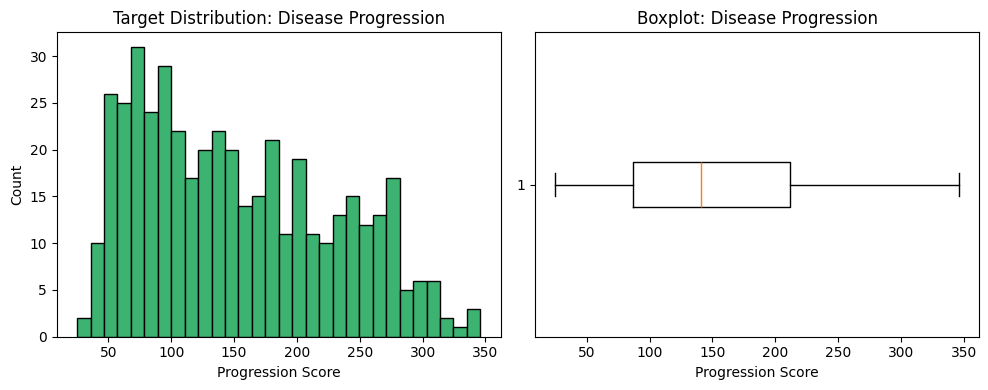

In [20]:
plt.figure(figsize=(10, 4))

# Left: Histogram
plt.subplot(1, 2, 1)
plt.hist(df['progression'], bins=30, color='mediumseagreen', edgecolor='black')
plt.title('Target Distribution: Disease Progression')
plt.xlabel('Progression Score')
plt.ylabel('Count')

# Right: Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['progression'], vert=False)
plt.title('Boxplot: Disease Progression')
plt.xlabel('Progression Score')

plt.tight_layout()
plt.show()

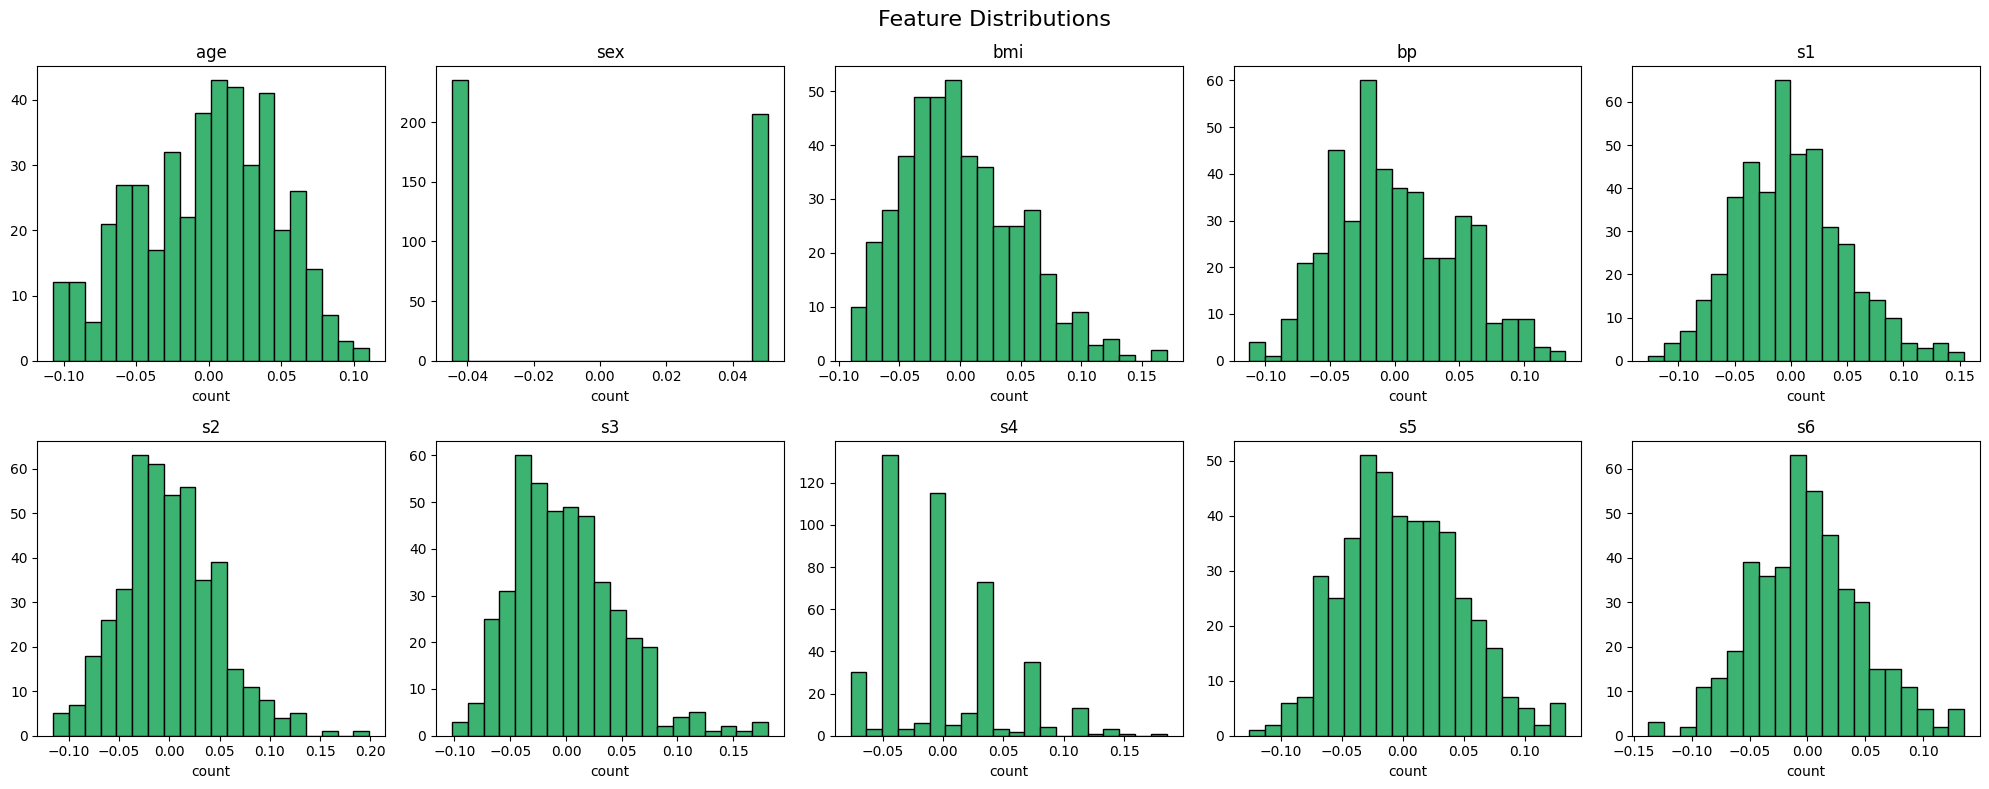

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, col in enumerate(diabetes.feature_names):
    ax = axes[i // 5][i % 5]
    ax.hist(df[col], bins=20, color='mediumseagreen', edgecolor='black' )
    ax.set_title(col)
    ax.set_xlabel('count')


plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

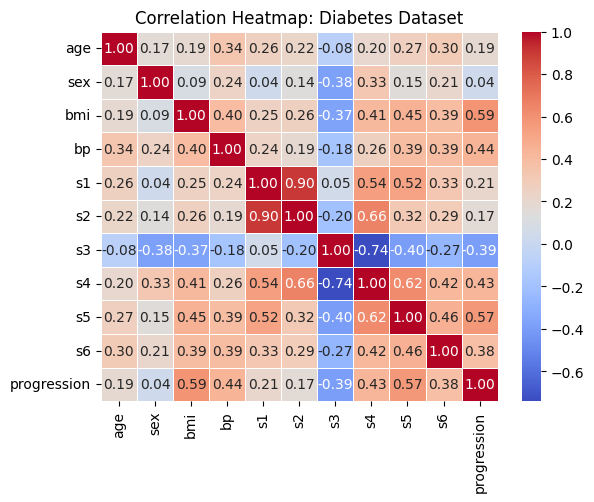

In [12]:
plt.Figure(figsize=(10, 8))
corr = df.corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Diabetes Dataset')
plt.show()

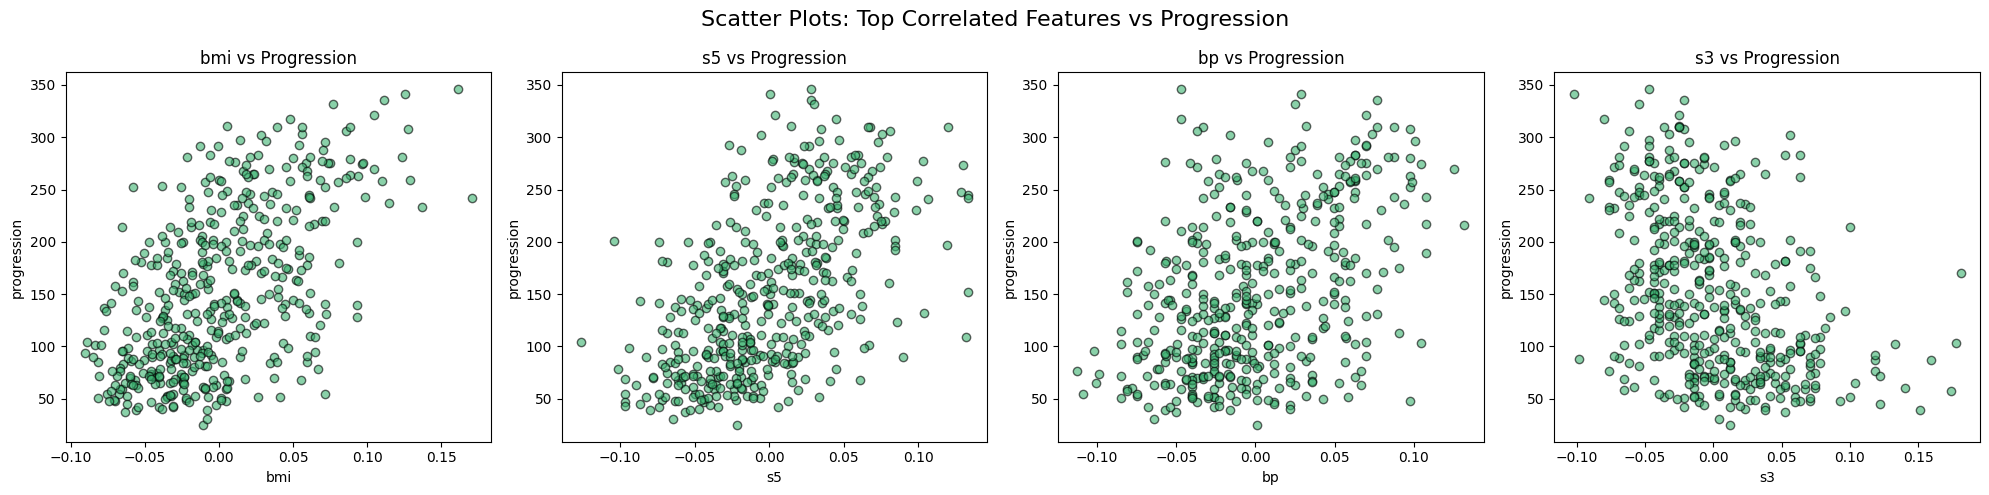

In [15]:
top_features = ['bmi', 's5', 'bp', 's3']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(top_features):
    axes[i].scatter(df[col], df["progression"], alpha=0.6, color='mediumseagreen', edgecolor='black')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('progression')
    axes[i].set_title(f'{col} vs Progression')

plt.suptitle('Scatter Plots: Top Correlated Features vs Progression', fontsize=16)
plt.tight_layout()
plt.show()


In [17]:
X = df.drop("progression", axis=1)
Y = df["progression"]

print(X.shape)
print(Y.shape)
print(list(X.columns))

(442, 10)
(442,)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape) 

(353, 10)
(89, 10)
(353,)
(89,)


In [20]:
print(X.mean().round(2))
print(X.std().round(2))

age   -0.0
sex    0.0
bmi   -0.0
bp    -0.0
s1    -0.0
s2     0.0
s3    -0.0
s4    -0.0
s5     0.0
s6     0.0
dtype: float64
age    0.05
sex    0.05
bmi    0.05
bp     0.05
s1     0.05
s2     0.05
s3     0.05
s4     0.05
s5     0.05
s6     0.05
dtype: float64


In [23]:
print(X_train.shape[0])
print(X_test.shape[0])
print(X_train.shape[1])
print(f'{Y_train.min(): .1f} {Y_train.max(): .1f}')


353
89
10
 25.0  346.0


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [27]:
lr = LinearRegression()
lr.fit(X_train, Y_train)

lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(Y_test, lr_pred)
lr_mse = mean_squared_error(Y_test, lr_pred)
lr_r2 = r2_score(Y_test, lr_pred)

print(f'Linear Regression - MAE: {lr_mae:.2f}, MSE: {lr_mse:.2f}, R²: {lr_r2:.2f}')

Linear Regression - MAE: 42.79, MSE: 2900.19, R²: 0.45


In [29]:
# Train
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, Y_train)

dt_pred = dt.predict(X_test)

dt_mae  = mean_absolute_error(Y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(Y_test, dt_pred))
dt_r2   = r2_score(Y_test, dt_pred)

print(f"Decision Tree - MAE: {dt_mae:.2f}, RMSE: {dt_rmse:.2f}, R²: {dt_r2:.2f}")

Decision Tree - MAE: 54.53, RMSE: 70.55, R²: 0.06


In [30]:

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

rf_pred = rf.predict(X_test)

rf_mae  = mean_absolute_error(Y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_pred))
rf_r2   = r2_score(Y_test, rf_pred)

print(f"Random Forest - MAE: {rf_mae:.2f}, RMSE: {rf_rmse:.2f}, R²: {rf_r2:.2f}")

Random Forest - MAE: 44.05, RMSE: 54.33, R²: 0.44


In [31]:

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, Y_train)

gb_pred = gb.predict(X_test)

gb_mae  = mean_absolute_error(Y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(Y_test, gb_pred))
gb_r2   = r2_score(Y_test, gb_pred)

print(f"Gradient Boosting - MAE: {gb_mae:.2f}, RMSE: {gb_rmse:.2f}, R²: {gb_r2:.2f}")

Gradient Boosting - MAE: 44.60, RMSE: 53.84, R²: 0.45


In [32]:
result = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'MAE': [lr_mae, dt_mae, rf_mae, gb_mae],
    'RMSE': [np.sqrt(lr_mse), dt_rmse, rf_rmse, gb_rmse],
    'R²': [lr_r2, dt_r2, rf_r2, gb_r2]
})

print(result)

               Model        MAE       RMSE        R²
0  Linear Regression  42.794095  53.853446  0.452603
1      Decision Tree  54.528090  70.546423  0.060654
2      Random Forest  44.053034  54.332408  0.442823
3  Gradient Boosting  44.603297  53.837131  0.452934
